# Malliavin Calculus and Monte-Carlo Methods — Project Notebook

Ce notebook reprend la **partie numérique du projet** sur les options asiatiques dans le modèle de Black–Scholes.

L'idée est de :
- simuler les trajectoires du sous-jacent ;
- approximer l'intégrale asiatique ;
- calculer les **prix Monte Carlo** ;
- comparer trois estimateurs du **Delta** :
  1. différences finies ;
  2. méthode de Malliavin A ;
  3. méthode de Malliavin B.

Le notebook est volontairement **autoportant** : si on exécute toutes les cellules dans l'ordre, il régénère les tableaux `.csv` et les graphiques `.png` utilisés dans le rapport.

## Rappel des paramètres du projet

On suit les paramètres imposés dans l'énoncé et repris dans le rapport :

$$
x=100,\qquad r=3\%,\qquad \sigma=20\%,\qquad T=1,
$$

avec trois niveaux de discrétisation $M\in\{50,150,250\}$ et

$$
N=1000,3000,5000,\dots,51000.
$$

Pour l'option asiatique discrétisée, on utilise

$$
A_M^x = \frac{T}{M}\sum_{k=0}^{M} X_{t_k}^x,\qquad t_k=\frac{kT}{M}.
$$

Pour le Delta, on compare :

- la méthode des différences finies avec **common random numbers** ;
- le poids de Malliavin **A** ;
- le poids de Malliavin **B**.

In [15]:
from dataclasses import dataclass
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

In [16]:
@dataclass
class Params:
    x: float = 100.0
    r: float = 0.03
    sigma: float = 0.20
    T: float = 1.0
    K1: float = 100.0
    K2: float = 110.0
    M_list: tuple = (50, 150, 250)
    N_grid: tuple = tuple(range(1000, 51001, 2000))
    eps_list: tuple = (0.25, 0.5, 1.0, 2.0, 5.0)
    seed: int = 123456

PARAMS = Params()
DISC = math.exp(-PARAMS.r * PARAMS.T)

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "notebook_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TAB_DIR = OUTPUT_DIR / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory :", ROOT)
print("Outputs will be written to:", OUTPUT_DIR)

Working directory : /Users/userxxxlocal/Documents/Malliavin
Outputs will be written to: /Users/userxxxlocal/Documents/Malliavin/notebook_outputs


## Fonctions de simulation et de synthèse

On exploite l'homogénéité du modèle en simulant les trajectoires normalisées $Z$ telles que

$$
X_{t_k}^x = x Z_{t_k}.
$$

Cela permet de réutiliser les mêmes trajectoires pour les différentes méthodes, ce qui est particulièrement utile pour les différences finies.

In [17]:
def simulate_normalized_paths(M: int, N: int, seed: int):
    """Simule Z_t tel que X_t^x = x Z_t dans Black-Scholes."""
    rng = np.random.default_rng(seed + M)
    dt = PARAMS.T / M
    dB = math.sqrt(dt) * rng.standard_normal(size=(N, M))
    log_increments = (PARAMS.r - 0.5 * PARAMS.sigma**2) * dt + PARAMS.sigma * dB

    Z = np.empty((N, M + 1))
    Z[:, 0] = 1.0
    Z[:, 1:] = np.exp(np.cumsum(log_increments, axis=1))
    return Z, dB, dt


def summarize(arr: np.ndarray):
    n = arr.size
    mean = arr.mean()
    var = arr.var(ddof=1)
    se = math.sqrt(var / n)
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se
    return mean, var, se, ci_low, ci_high

In [18]:
def build_estimators_for_M(M: int, Nmax: int):
    """Construit tous les échantillons Monte Carlo utiles pour un M donné."""
    Z, dB, dt = simulate_normalized_paths(M=M, N=Nmax, seed=PARAMS.seed)

    A1 = dt * np.sum(Z, axis=1)      # A_M quand x = 1
    A_x = PARAMS.x * A1              # A_M^x

    payoff_call = np.maximum(A_x - PARAMS.K1, 0.0)
    payoff_digital = ((A_x > PARAMS.K1) & (A_x < PARAMS.K2)).astype(float)

    price_samples = {
        "call": DISC * payoff_call,
        "digital": DISC * payoff_digital,
    }

    # Malliavin A
    pi_A = dB[:, 0] / (PARAMS.x * PARAMS.sigma * dt)

    # Malliavin B
    stochastic_integral = np.sum(Z[:, :-1] * dB, axis=1)
    pi_B = 1.0 / PARAMS.x + 2.0 / (PARAMS.x * PARAMS.sigma * A1) * stochastic_integral

    delta_samples = {
        ("malliavin_A", "call"): DISC * payoff_call * pi_A,
        ("malliavin_A", "digital"): DISC * payoff_digital * pi_A,
        ("malliavin_B", "call"): DISC * payoff_call * pi_B,
        ("malliavin_B", "digital"): DISC * payoff_digital * pi_B,
    }

    # Différences finies avec common random numbers
    for eps in PARAMS.eps_list:
        A_plus = (PARAMS.x + eps) * A1
        A_minus = (PARAMS.x - eps) * A1

        fd_call = DISC * (
            np.maximum(A_plus - PARAMS.K1, 0.0) - np.maximum(A_minus - PARAMS.K1, 0.0)
        ) / (2.0 * eps)

        fd_digital = DISC * (
            ((A_plus > PARAMS.K1) & (A_plus < PARAMS.K2)).astype(float)
            - ((A_minus > PARAMS.K1) & (A_minus < PARAMS.K2)).astype(float)
        ) / (2.0 * eps)

        delta_samples[(f"FD_eps_{eps}", "call")] = fd_call
        delta_samples[(f"FD_eps_{eps}", "digital")] = fd_digital

    return {
        "Z": Z,
        "dB": dB,
        "dt": dt,
        "A1": A1,
        "price_samples": price_samples,
        "delta_samples": delta_samples,
    }

## Lancement complet des simulations
Cette cellule exécute toute l'étude numérique, construit les tableaux et sauvegarde les CSV.

In [19]:
Nmax = max(PARAMS.N_grid)
all_results = {M: build_estimators_for_M(M, Nmax) for M in PARAMS.M_list}

summary_rows = []
convergence_rows = []
eps_rows = []

for M in PARAMS.M_list:
    res = all_results[M]

    for option in ("call", "digital"):
        mean, var, se, ci_low, ci_high = summarize(res["price_samples"][option])
        summary_rows.append(
            {
                "M": M,
                "type": "price",
                "method": "MC",
                "option": option,
                "estimate": mean,
                "variance": var,
                "std_error": se,
                "ci_low": ci_low,
                "ci_high": ci_high,
            }
        )

    methods = ["malliavin_A", "malliavin_B"] + [f"FD_eps_{eps}" for eps in PARAMS.eps_list]
    for method in methods:
        for option in ("call", "digital"):
            mean, var, se, ci_low, ci_high = summarize(res["delta_samples"][(method, option)])
            summary_rows.append(
                {
                    "M": M,
                    "type": "delta",
                    "method": method,
                    "option": option,
                    "estimate": mean,
                    "variance": var,
                    "std_error": se,
                    "ci_low": ci_low,
                    "ci_high": ci_high,
                }
            )

    for N in PARAMS.N_grid:
        for option in ("call", "digital"):
            mean, var, se, ci_low, ci_high = summarize(res["price_samples"][option][:N])
            convergence_rows.append(
                {
                    "kind": "price",
                    "M": M,
                    "N": N,
                    "method": "MC",
                    "option": option,
                    "estimate": mean,
                    "variance": var,
                    "ci_width": ci_high - ci_low,
                }
            )

        for method in ("malliavin_A", "malliavin_B", "FD_eps_1.0"):
            for option in ("call", "digital"):
                mean, var, se, ci_low, ci_high = summarize(res["delta_samples"][(method, option)][:N])
                convergence_rows.append(
                    {
                        "kind": "delta",
                        "M": M,
                        "N": N,
                        "method": method,
                        "option": option,
                        "estimate": mean,
                        "variance": var,
                        "ci_width": ci_high - ci_low,
                    }
                )

    for eps in PARAMS.eps_list:
        for option in ("call", "digital"):
            mean, var, se, ci_low, ci_high = summarize(res["delta_samples"][(f"FD_eps_{eps}", option)])
            eps_rows.append(
                {
                    "M": M,
                    "epsilon": eps,
                    "option": option,
                    "estimate": mean,
                    "variance": var,
                    "ci_width": ci_high - ci_low,
                }
            )

summary_df = pd.DataFrame(summary_rows)
convergence_df = pd.DataFrame(convergence_rows)
eps_df = pd.DataFrame(eps_rows)

summary_df.to_csv(TAB_DIR / "summary_results_N51000.csv", index=False)
convergence_df.to_csv(TAB_DIR / "convergence_results.csv", index=False)
eps_df.to_csv(TAB_DIR / "fd_epsilon_effect.csv", index=False)

print("CSV files saved in:", TAB_DIR)

CSV files saved in: /Users/userxxxlocal/Documents/Malliavin/notebook_outputs/tables


## Tableaux principaux du rapport

In [20]:
price_table = summary_df[summary_df["type"] == "price"].copy()
price_table["option"] = price_table["option"].replace({"call": "Call asiatique", "digital": "Digitale asiatique"})
price_table[["M", "option", "estimate", "variance", "ci_low", "ci_high"]]

,M,option,estimate,variance,ci_low,ci_high
0,50,Call asiatique,6.420827,71.085957,6.347652,6.494002
1,50,Digitale asiatique,0.307936,0.204014,0.304016,0.311856
16,150,Call asiatique,5.631705,63.227995,5.562693,5.700717
17,150,Digitale asiatique,0.293398,0.198648,0.289530,0.297266
32,250,Call asiatique,5.479979,61.875994,5.411709,5.548249
33,250,Digitale asiatique,0.293512,0.198692,0.289644,0.297381


In [21]:
delta_call_table = summary_df[
    (summary_df["type"] == "delta")
    & (summary_df["option"] == "call")
    & (summary_df["method"].isin(["FD_eps_1.0", "malliavin_A", "malliavin_B"]))
].copy()
delta_call_table["method"] = delta_call_table["method"].replace({
    "FD_eps_1.0": "FD (eps=1)",
    "malliavin_A": "Malliavin A",
    "malliavin_B": "Malliavin B",
})
delta_call_table[["M", "method", "estimate", "variance", "ci_low", "ci_high"]]

,M,method,estimate,variance,ci_low,ci_high
2,50,Malliavin A,0.634433,15.330350,0.600452,0.668415
4,50,Malliavin B,0.618507,2.092157,0.605953,0.631060
10,50,FD (eps=1),0.639819,0.274169,0.635275,0.644364
18,150,Malliavin A,0.589638,36.550022,0.537168,0.642109
20,150,Malliavin B,0.580577,1.931113,0.568516,0.592637
26,150,FD (eps=1),0.584680,0.279071,0.580095,0.589265
34,250,Malliavin A,0.601152,57.646808,0.535256,0.667048
36,250,Malliavin B,0.571958,1.878118,0.560064,0.583852
42,250,FD (eps=1),0.575524,0.278644,0.570943,0.580106


In [22]:
delta_digital_table = summary_df[
    (summary_df["type"] == "delta")
    & (summary_df["option"] == "digital")
    & (summary_df["method"].isin(["FD_eps_1.0", "malliavin_A", "malliavin_B"]))
].copy()
delta_digital_table["method"] = delta_digital_table["method"].replace({
    "FD_eps_1.0": "FD (eps=1)",
    "malliavin_A": "Malliavin A",
    "malliavin_B": "Malliavin B",
})
delta_digital_table[["M", "method", "estimate", "variance", "ci_low", "ci_high"]]

,M,method,estimate,variance,ci_low,ci_high
3,50,Malliavin A,0.004983,0.035207,0.003354,0.006611
5,50,Malliavin B,0.004959,0.000886,0.004700,0.005217
11,50,FD (eps=1),0.005851,0.029609,0.004358,0.007345
19,150,Malliavin A,0.006440,0.106084,0.003614,0.009267
21,150,Malliavin B,0.007336,0.000954,0.007068,0.007604
27,150,FD (eps=1),0.007060,0.028204,0.005602,0.008517
35,250,Malliavin A,0.008164,0.177476,0.004508,0.011821
37,250,Malliavin B,0.007916,0.000985,0.007643,0.008188
43,250,FD (eps=1),0.008705,0.028561,0.007239,0.010172


## Graphiques
Les cellules suivantes reproduisent les graphiques utiles pour la partie C du rapport.

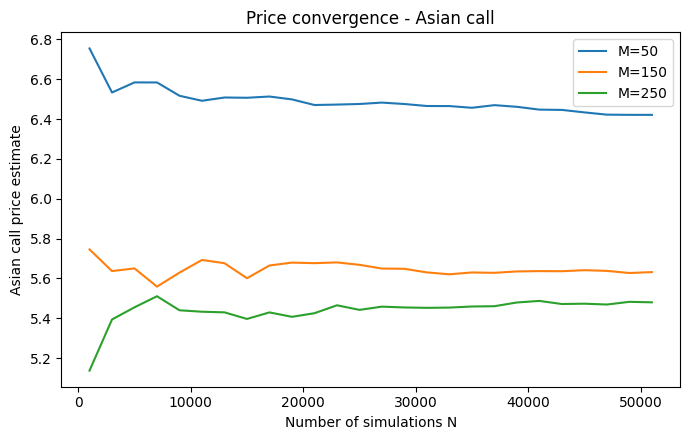

In [23]:
plt.figure(figsize=(7, 4.5))
for M in PARAMS.M_list:
    sub = convergence_df[
        (convergence_df["kind"] == "price")
        & (convergence_df["option"] == "call")
        & (convergence_df["M"] == M)
    ]
    plt.plot(sub["N"], sub["estimate"], label=f"M={M}")
plt.xlabel("Number of simulations N")
plt.ylabel("Asian call price estimate")
plt.title("Price convergence - Asian call")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "price_convergence_call.png", dpi=200)
plt.show()

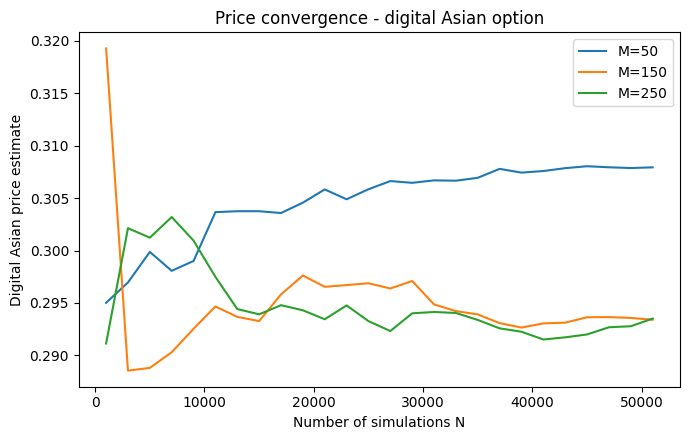

In [24]:
plt.figure(figsize=(7, 4.5))
for M in PARAMS.M_list:
    sub = convergence_df[
        (convergence_df["kind"] == "price")
        & (convergence_df["option"] == "digital")
        & (convergence_df["M"] == M)
    ]
    plt.plot(sub["N"], sub["estimate"], label=f"M={M}")
plt.xlabel("Number of simulations N")
plt.ylabel("Digital Asian price estimate")
plt.title("Price convergence - digital Asian option")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "price_convergence_digital.png", dpi=200)
plt.show()

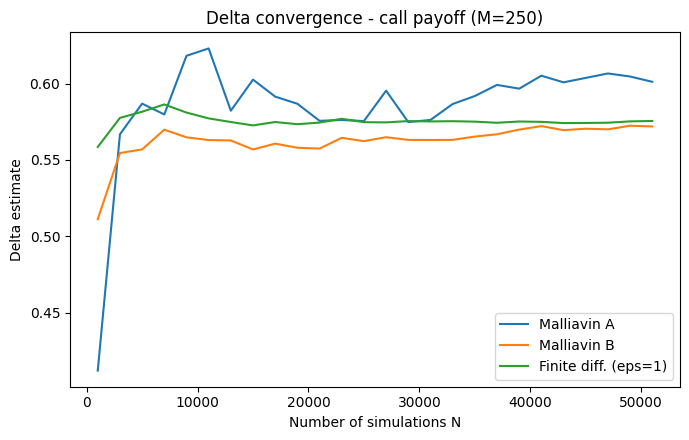

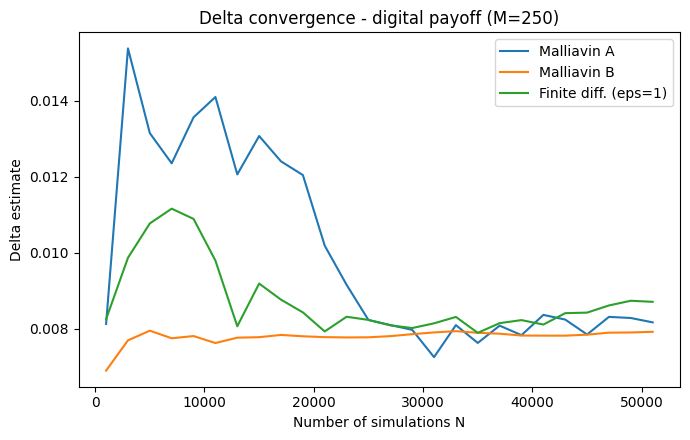

In [25]:
for option in ("call", "digital"):
    plt.figure(figsize=(7, 4.5))
    for method, label in (
        ("malliavin_A", "Malliavin A"),
        ("malliavin_B", "Malliavin B"),
        ("FD_eps_1.0", "Finite diff. (eps=1)"),
    ):
        sub = convergence_df[
            (convergence_df["kind"] == "delta")
            & (convergence_df["option"] == option)
            & (convergence_df["M"] == 250)
            & (convergence_df["method"] == method)
        ]
        plt.plot(sub["N"], sub["estimate"], label=label)
    plt.xlabel("Number of simulations N")
    plt.ylabel("Delta estimate")
    plt.title(f"Delta convergence - {option} payoff (M=250)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"delta_convergence_{option}_M250.png", dpi=200)
    plt.show()

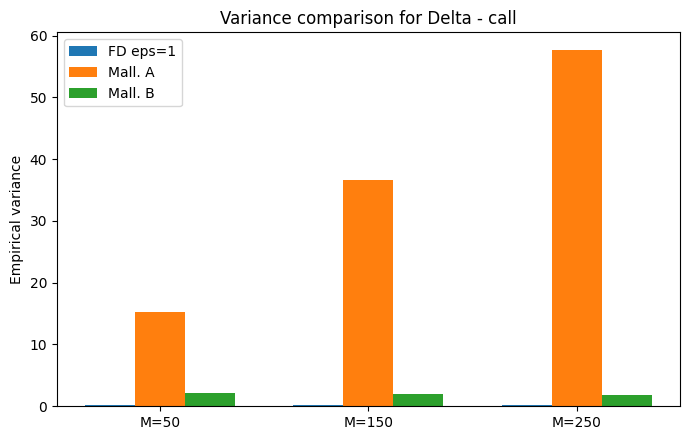

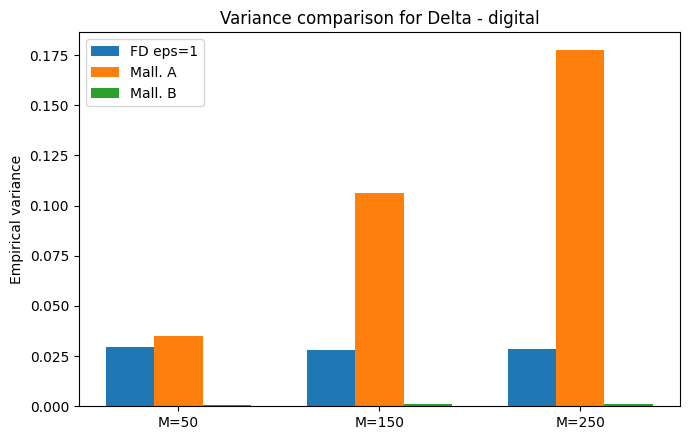

In [26]:
for option in ("call", "digital"):
    plot_df = summary_df[
        (summary_df["type"] == "delta")
        & (summary_df["option"] == option)
        & (summary_df["method"].isin(["FD_eps_1.0", "malliavin_A", "malliavin_B"]))
    ]
    xloc = np.arange(len(PARAMS.M_list))
    width = 0.24

    plt.figure(figsize=(7, 4.5))
    for idx, (method, label) in enumerate(
        (("FD_eps_1.0", "FD eps=1"), ("malliavin_A", "Mall. A"), ("malliavin_B", "Mall. B"))
    ):
        vals = [
            plot_df[(plot_df["M"] == M) & (plot_df["method"] == method)]["variance"].iloc[0]
            for M in PARAMS.M_list
        ]
        plt.bar(xloc + idx * width - width, vals, width=width, label=label)

    plt.xticks(xloc, [f"M={M}" for M in PARAMS.M_list])
    plt.ylabel("Empirical variance")
    plt.title(f"Variance comparison for Delta - {option}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"variance_comparison_delta_{option}.png", dpi=200)
    plt.show()

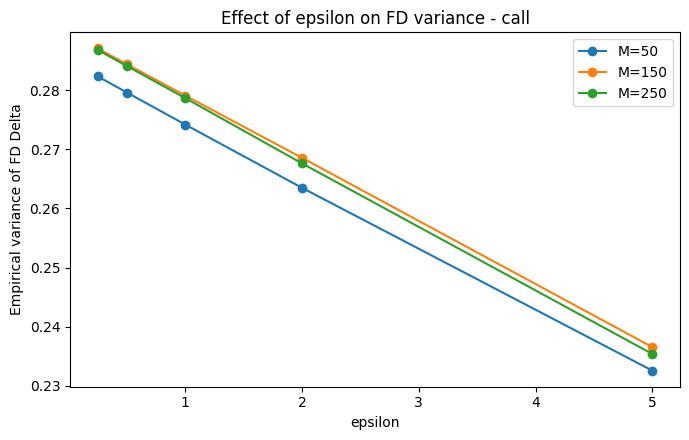

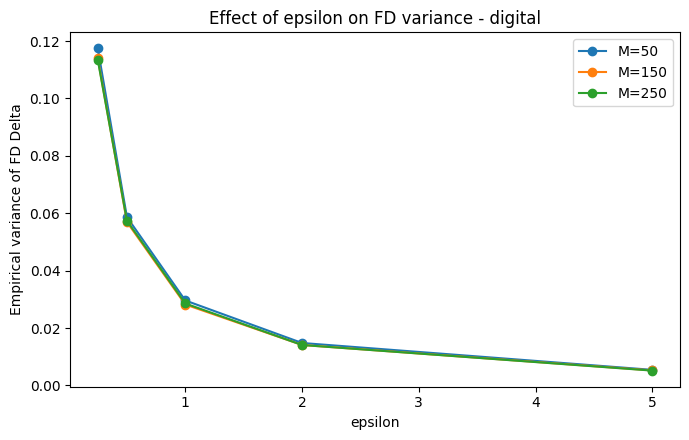

In [27]:
for option in ("call", "digital"):
    plt.figure(figsize=(7, 4.5))
    for M in PARAMS.M_list:
        sub = eps_df[(eps_df["option"] == option) & (eps_df["M"] == M)]
        plt.plot(sub["epsilon"], sub["variance"], marker="o", label=f"M={M}")
    plt.xlabel("epsilon")
    plt.ylabel("Empirical variance of FD Delta")
    plt.title(f"Effect of epsilon on FD variance - {option}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fd_epsilon_variance_{option}.png", dpi=200)
    plt.show()

## Lecture rapide des résultats

Le notebook permet de retrouver les messages principaux du rapport :

- pour le **call asiatique**, les différences finies et Malliavin B sont proches ;
- la méthode **Malliavin A** est plus bruitée ;
- pour la **digitale asiatique**, Malliavin B est nettement plus stable en variance ;
- l'effet de \(\varepsilon\) est plus sensible pour la digitale que pour le call.

In [28]:
digital_compare = summary_df[
    (summary_df["type"] == "delta")
    & (summary_df["option"] == "digital")
    & (summary_df["method"].isin(["FD_eps_1.0", "malliavin_B"]))
].copy()

rows = []
for M in PARAMS.M_list:
    var_fd = digital_compare[(digital_compare["M"] == M) & (digital_compare["method"] == "FD_eps_1.0")]["variance"].iloc[0]
    var_mb = digital_compare[(digital_compare["M"] == M) & (digital_compare["method"] == "malliavin_B")]["variance"].iloc[0]
    rows.append({"M": M, "Var(FD)": var_fd, "Var(Mall_B)": var_mb, "Ratio FD / Mall_B": var_fd / var_mb})

pd.DataFrame(rows)

,M,Var(FD),Var(Mall_B),Ratio FD / Mall_B
0,50,0.029609,0.000886,33.430346
1,150,0.028204,0.000954,29.566415
2,250,0.028561,0.000985,28.988198
